# 📊 COVID-19 Data Visualization Dashboard
**Horizon TechX AI & Data Science Internship | Task 4**  
**Author:** Mani Chelluri   
**Dataset:** Our World in Data — COVID-19 Dataset (Jan 2020 – Aug 2024)  
**Stack:** Python · Pandas · Matplotlib · Seaborn

---

## 📌 Objective
Convert the COVID-19 dataset into a multi-panel, publication-quality dashboard  
designed for **decision-making and storytelling** — not just exploration.  
Each panel answers a specific public health question at a glance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--'
})

BG      = '#0D1117'
ACCENT1 = '#E63946'
ACCENT2 = '#457B9D'
ACCENT3 = '#2A9D8F'
ACCENT4 = '#E9C46A'
ACCENT5 = '#F4A261'
ACCENT6 = '#264653'
WHITE   = '#F1FAEE'

CONT_COLORS = {
    'Asia'          : ACCENT1,
    'Europe'        : ACCENT2,
    'North America' : ACCENT3,
    'South America' : ACCENT4,
    'Africa'        : ACCENT5,
    'Oceania'       : ACCENT6
}
print('Dashboard imports ready.')


Dashboard imports ready.


## 1️⃣  Load & Prepare Data

In [2]:
df_raw = pd.read_csv('owid-covid-data.csv', parse_dates=['date'])
df     = df_raw[df_raw['continent'].notna()].copy()

cols = [
    'iso_code','continent','location','date',
    'total_cases','new_cases','total_deaths','new_deaths',
    'total_vaccinations','people_vaccinated','people_fully_vaccinated',
    'total_cases_per_million','total_deaths_per_million',
    'population','median_age','gdp_per_capita','human_development_index'
]
df = df[cols].sort_values(['location','date'])
cum_cols = ['total_cases','total_deaths','total_vaccinations',
            'people_vaccinated','people_fully_vaccinated']
df[cum_cols] = df.groupby('location')[cum_cols].ffill()
df['death_rate'] = (df['total_deaths'] / df['total_cases'] * 100).round(4)
df['vacc_rate']  = (df['people_fully_vaccinated'] / df['population'] * 100).round(4)

latest = df.sort_values('date').groupby('location').last().reset_index()

global_daily = (df.groupby('date')
                  .agg(
                      total_cases  = ('total_cases',  'sum'),
                      total_deaths = ('total_deaths', 'sum'),
                      new_cases    = ('new_cases',    'sum'),
                      new_deaths   = ('new_deaths',   'sum')
                  ).reset_index())
global_daily['new_cases_7d']  = global_daily['new_cases'].rolling(7).mean()
global_daily['new_deaths_7d'] = global_daily['new_deaths'].rolling(7).mean()

top10_cases  = latest.nlargest(10, 'total_cases')
top5_list    = top10_cases['location'].head(5).tolist()

print('Data ready for dashboard.')
print(f'Countries: {latest.shape[0]} | Date range: {df.date.min().date()} -> {df.date.max().date()}')


Data ready for dashboard.
Countries: 243 | Date range: 2020-01-01 -> 2024-08-14


## 2️⃣  Dashboard 1 — Global Overview

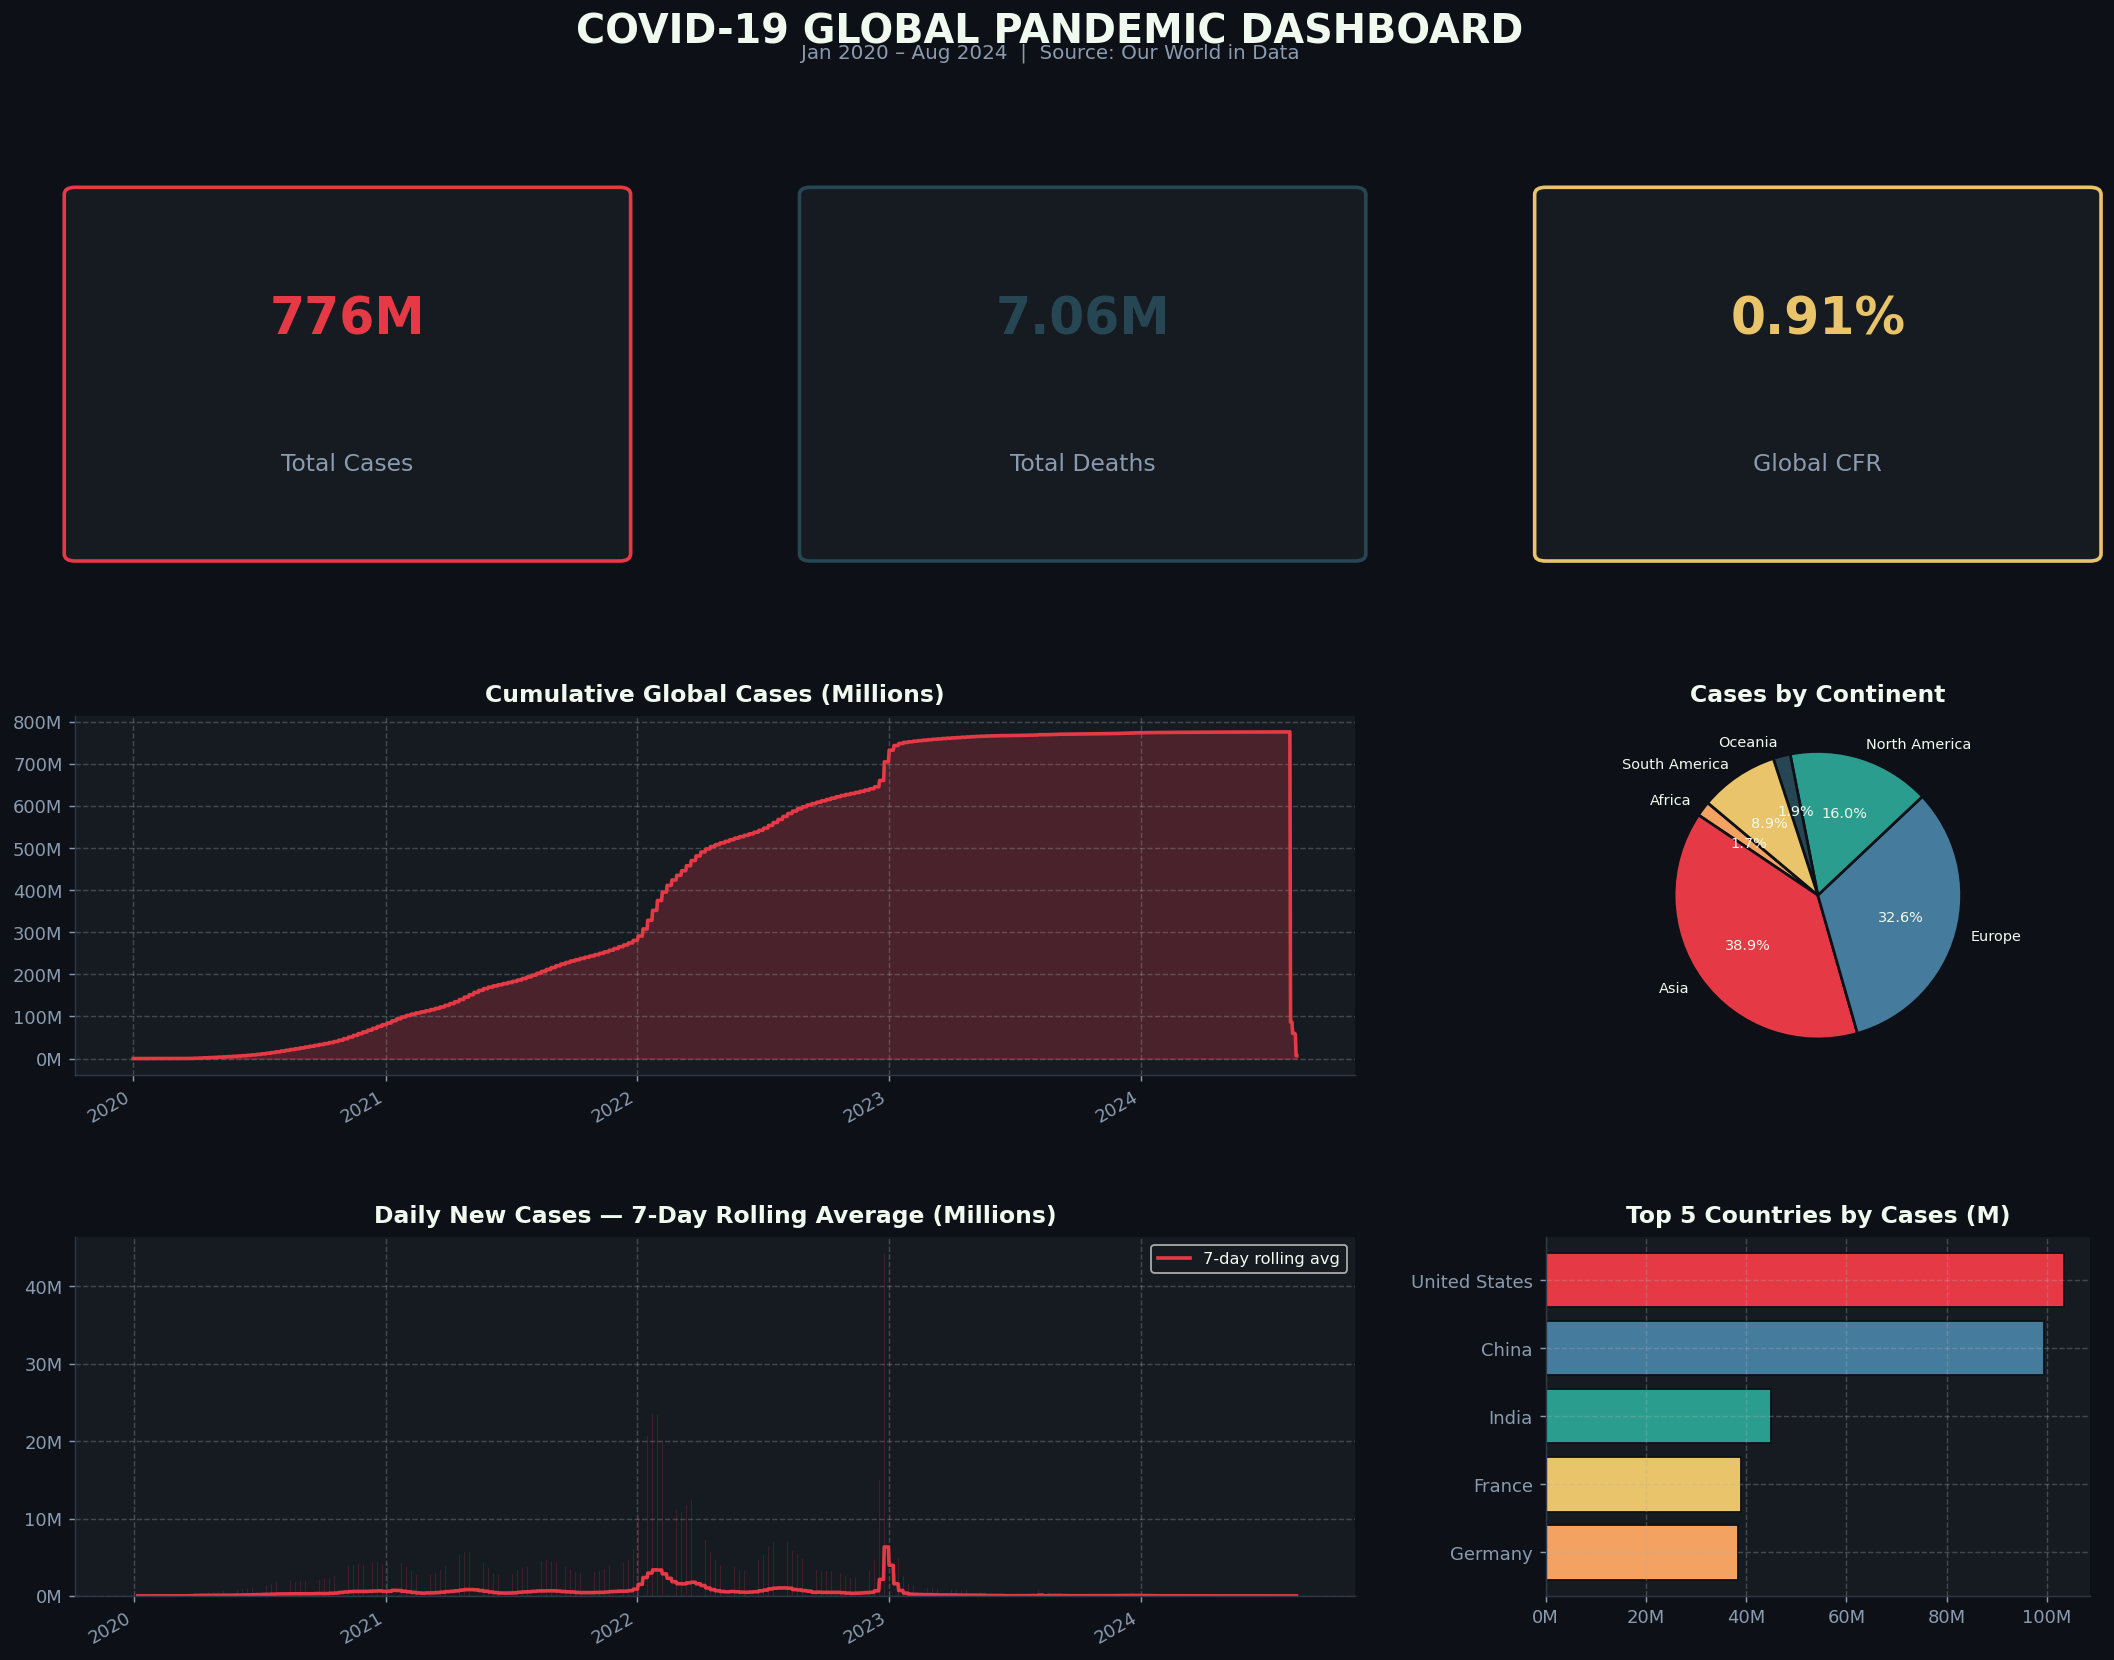

Dashboard 1 saved.


In [3]:
fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('COVID-19 GLOBAL PANDEMIC DASHBOARD',
             fontsize=22, fontweight='bold', color=WHITE, y=0.98)
fig.text(0.5, 0.955, 'Jan 2020 – Aug 2024  |  Source: Our World in Data',
         ha='center', fontsize=11, color='#8B9BAF')

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI Cards (row 0) ─────────────────────────────────────────────────────────
kpis = [
    ('Total Cases',   f"{latest['total_cases'].sum()/1e6:.0f}M",  ACCENT1),
    ('Total Deaths',  f"{latest['total_deaths'].sum()/1e6:.2f}M", ACCENT6),
    ('Global CFR',
     f"{latest['total_deaths'].sum()/latest['total_cases'].sum()*100:.2f}%",
     ACCENT4),
]
for col_idx, (title, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, col_idx])
    ax.set_facecolor('#161B22')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=28, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center',
            fontsize=13, color='#8B9BAF', transform=ax.transAxes)
    for spine in ['top','right','bottom','left']:
        ax.spines[spine].set_visible(False)
    rect = mpatches.FancyBboxPatch((0,0), 1, 1, boxstyle='round,pad=0.02',
                                    linewidth=2, edgecolor=color,
                                    facecolor='#161B22',
                                    transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)

# ── Cumulative Cases Timeline (row 1, col 0-1) ────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
ax1.set_facecolor('#161B22')
ax1.fill_between(global_daily['date'],
                  global_daily['total_cases']/1e6,
                  color=ACCENT1, alpha=0.25)
ax1.plot(global_daily['date'],
         global_daily['total_cases']/1e6,
         color=ACCENT1, linewidth=2)
ax1.set_title('Cumulative Global Cases (Millions)',
              color=WHITE, fontsize=13, fontweight='bold', pad=8)
ax1.tick_params(colors='#8B9BAF')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax1.set_facecolor('#161B22')
for spine in ax1.spines.values(): spine.set_color('#2D3748')
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right', color='#8B9BAF')

# ── Continent Pie (row 1, col 2) ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2])
ax2.set_facecolor('#161B22')
cont_cases = latest.groupby('continent')['total_cases'].sum()
colors_pie  = [CONT_COLORS.get(c, '#888') for c in cont_cases.index]
ax2.pie(cont_cases.values, labels=cont_cases.index,
        colors=colors_pie, autopct='%1.1f%%', startangle=140,
        wedgeprops=dict(edgecolor=BG, linewidth=1.5),
        textprops={'fontsize': 8, 'color': WHITE})
ax2.set_title('Cases by Continent', color=WHITE,
              fontsize=13, fontweight='bold', pad=8)

# ── Daily New Cases 7d (row 2, col 0-1) ──────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0:2])
ax3.set_facecolor('#161B22')
ax3.bar(global_daily['date'],
        global_daily['new_cases']/1e6,
        color=ACCENT1, alpha=0.2, width=1)
ax3.plot(global_daily['date'],
         global_daily['new_cases_7d']/1e6,
         color=ACCENT1, linewidth=2, label='7-day rolling avg')
ax3.set_title('Daily New Cases — 7-Day Rolling Average (Millions)',
              color=WHITE, fontsize=13, fontweight='bold', pad=8)
ax3.legend(facecolor='#161B22', labelcolor=WHITE, fontsize=9)
ax3.tick_params(colors='#8B9BAF')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
for spine in ax3.spines.values(): spine.set_color('#2D3748')
plt.setp(ax3.get_xticklabels(), rotation=30, ha='right', color='#8B9BAF')

# ── Top 5 Countries Bar (row 2, col 2) ────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 2])
ax4.set_facecolor('#161B22')
top5_df = top10_cases.head(5)
bars = ax4.barh(top5_df['location'],
                top5_df['total_cases']/1e6,
                color=[ACCENT1,ACCENT2,ACCENT3,ACCENT4,ACCENT5],
                edgecolor=BG)
ax4.set_title('Top 5 Countries by Cases (M)',
              color=WHITE, fontsize=13, fontweight='bold', pad=8)
ax4.invert_yaxis()
ax4.tick_params(colors='#8B9BAF')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
for spine in ax4.spines.values(): spine.set_color('#2D3748')

plt.savefig('dash_01_global_overview.png', bbox_inches='tight',
            facecolor=BG, dpi=130)
plt.show()
print('Dashboard 1 saved.')


## 3️⃣  Dashboard 2 — Country Deep-Dive

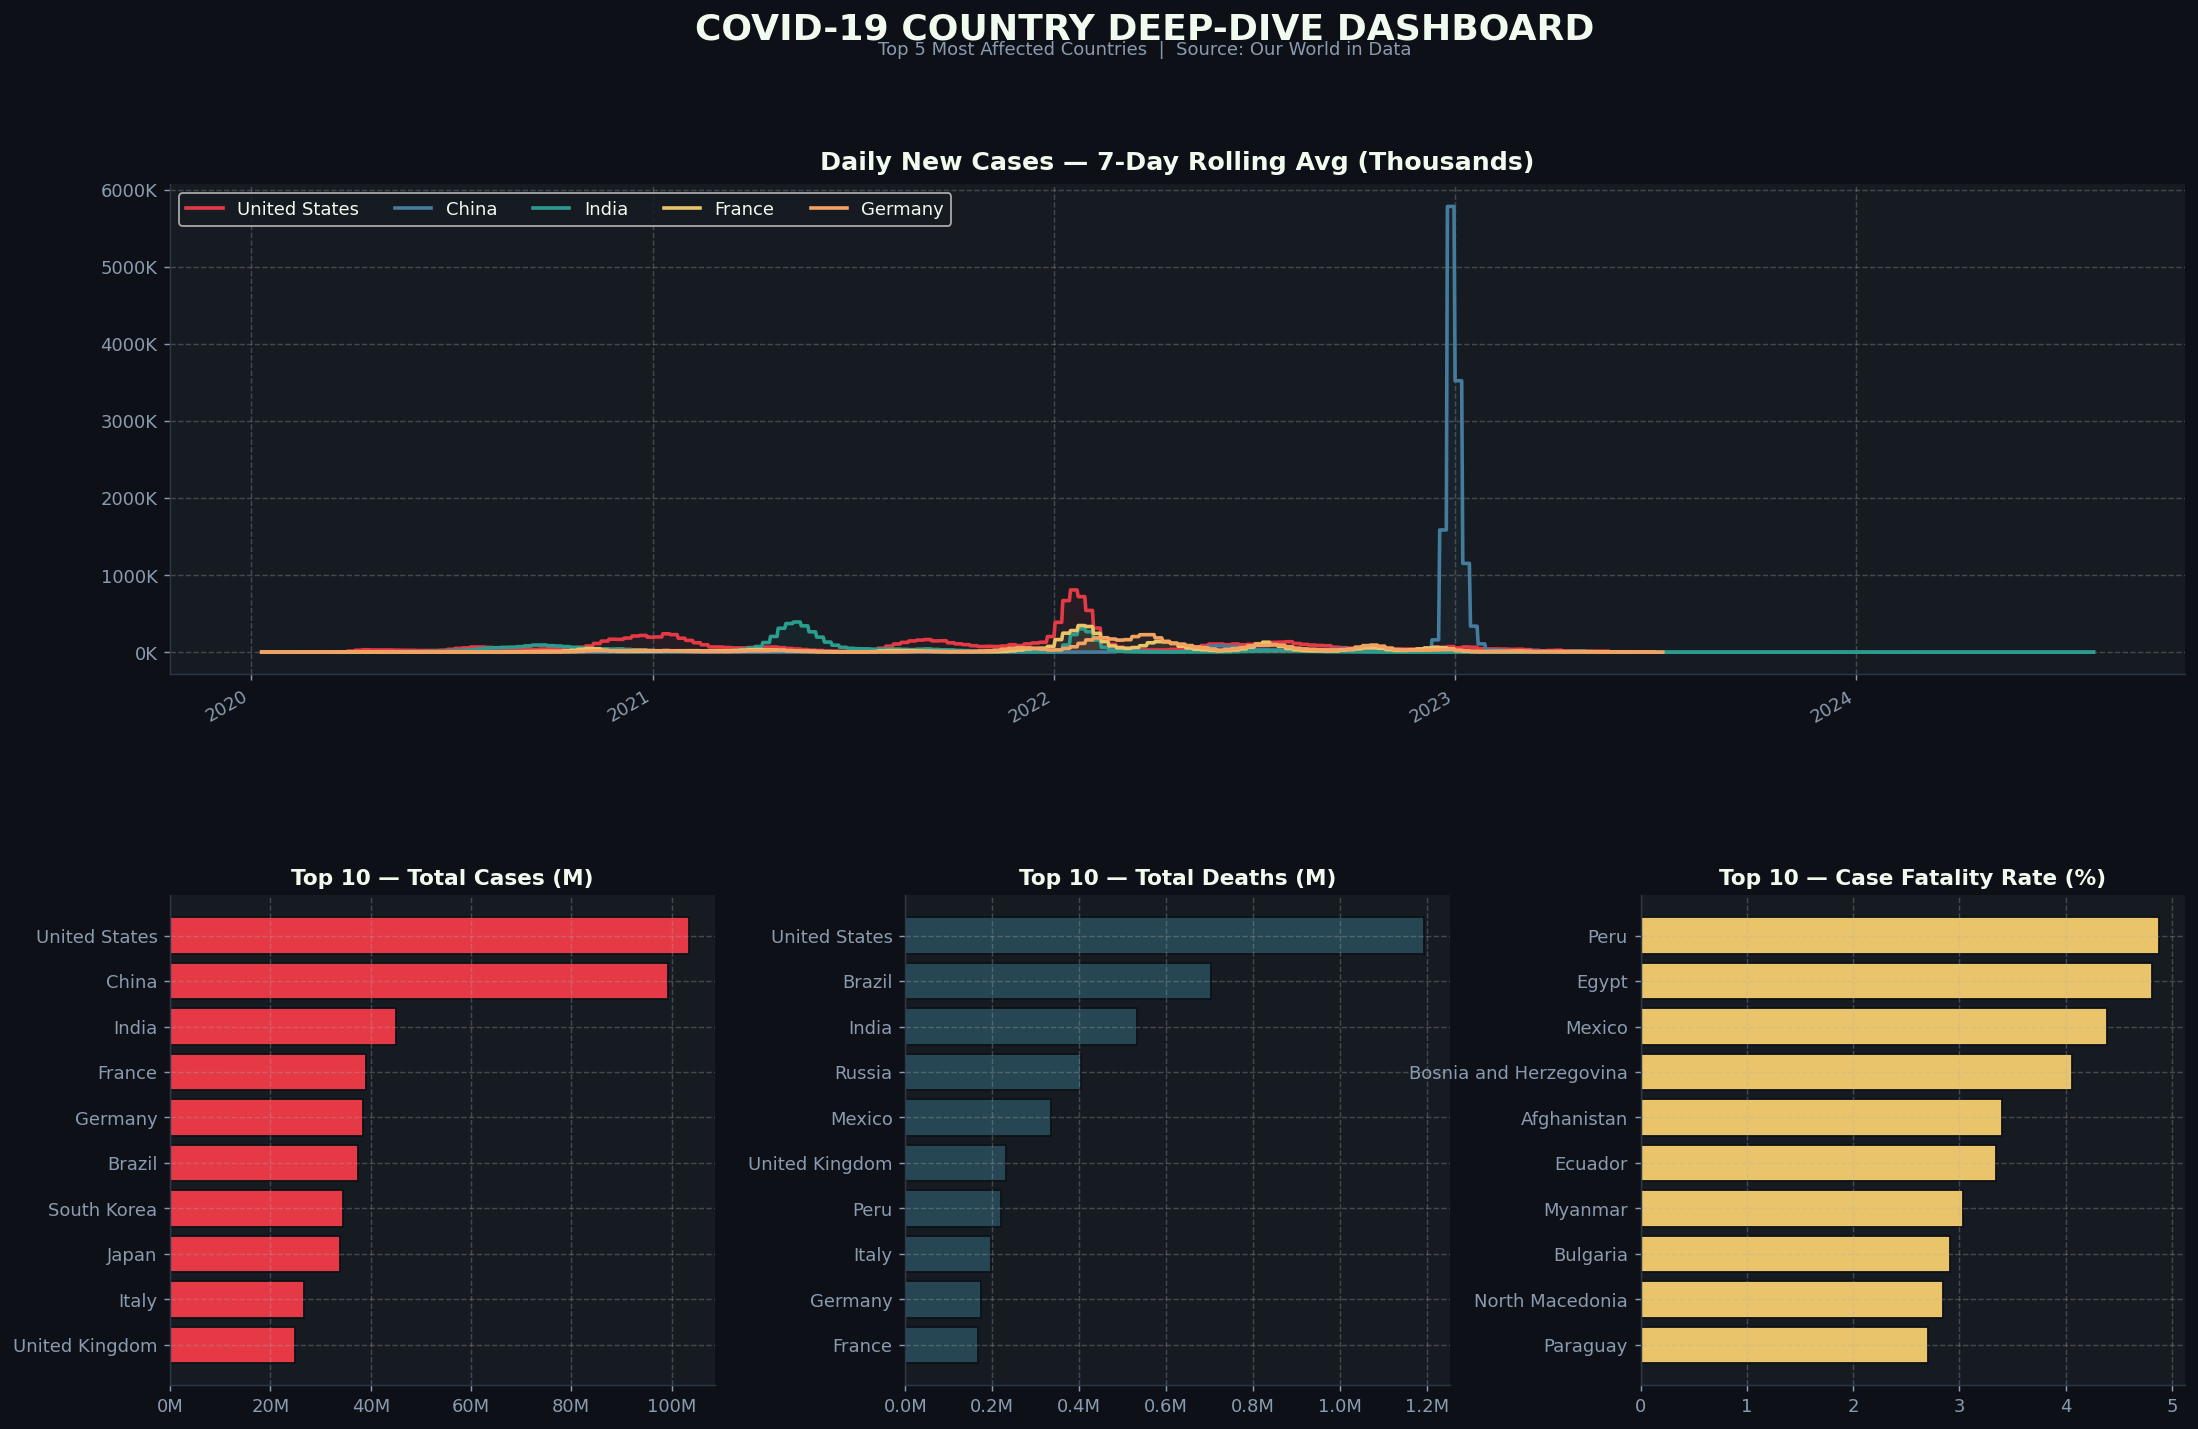

Dashboard 2 saved.


In [4]:
fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle('COVID-19 COUNTRY DEEP-DIVE DASHBOARD',
             fontsize=20, fontweight='bold', color=WHITE, y=0.99)
fig.text(0.5, 0.963, 'Top 5 Most Affected Countries  |  Source: Our World in Data',
         ha='center', fontsize=10, color='#8B9BAF')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

df_top5 = df[df['location'].isin(top5_list)].copy()

# ── Wave Chart (row 0, all cols) ──────────────────────────────────────────────
ax_wave = fig.add_subplot(gs[0, :])
ax_wave.set_facecolor('#161B22')
palette = [ACCENT1, ACCENT2, ACCENT3, ACCENT4, ACCENT5]
for country, color in zip(top5_list, palette):
    data = df_top5[df_top5['location'] == country].copy()
    data['new_cases_7d'] = data['new_cases'].rolling(7).mean()
    ax_wave.plot(data['date'], data['new_cases_7d']/1e3,
                 color=color, linewidth=2, label=country)
    ax_wave.fill_between(data['date'], data['new_cases_7d']/1e3,
                         color=color, alpha=0.08)

ax_wave.set_title('Daily New Cases — 7-Day Rolling Avg (Thousands)',
                  color=WHITE, fontsize=14, fontweight='bold', pad=8)
ax_wave.legend(facecolor='#161B22', labelcolor=WHITE, fontsize=10,
               loc='upper left', ncol=5)
ax_wave.tick_params(colors='#8B9BAF')
ax_wave.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
for spine in ax_wave.spines.values(): spine.set_color('#2D3748')
plt.setp(ax_wave.get_xticklabels(), rotation=30, ha='right', color='#8B9BAF')

# ── Total Cases Bar (row 1, col 0) ────────────────────────────────────────────
top10 = latest.nlargest(10, 'total_cases')
ax_cases = fig.add_subplot(gs[1, 0])
ax_cases.set_facecolor('#161B22')
ax_cases.barh(top10['location'], top10['total_cases']/1e6,
              color=ACCENT1, edgecolor=BG)
ax_cases.set_title('Top 10 — Total Cases (M)',
                   color=WHITE, fontsize=12, fontweight='bold')
ax_cases.invert_yaxis()
ax_cases.tick_params(colors='#8B9BAF')
ax_cases.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
for spine in ax_cases.spines.values(): spine.set_color('#2D3748')

# ── Total Deaths Bar (row 1, col 1) ───────────────────────────────────────────
top10_d = latest.nlargest(10, 'total_deaths')
ax_deaths = fig.add_subplot(gs[1, 1])
ax_deaths.set_facecolor('#161B22')
ax_deaths.barh(top10_d['location'], top10_d['total_deaths']/1e6,
               color=ACCENT6, edgecolor=BG)
ax_deaths.set_title('Top 10 — Total Deaths (M)',
                    color=WHITE, fontsize=12, fontweight='bold')
ax_deaths.invert_yaxis()
ax_deaths.tick_params(colors='#8B9BAF')
ax_deaths.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
for spine in ax_deaths.spines.values(): spine.set_color('#2D3748')

# ── CFR Bar (row 1, col 2) ────────────────────────────────────────────────────
top10_r = latest[latest['total_cases'] > 100000].nlargest(10, 'death_rate')
ax_cfr = fig.add_subplot(gs[1, 2])
ax_cfr.set_facecolor('#161B22')
ax_cfr.barh(top10_r['location'], top10_r['death_rate'],
            color=ACCENT4, edgecolor=BG)
ax_cfr.set_title('Top 10 — Case Fatality Rate (%)',
                 color=WHITE, fontsize=12, fontweight='bold')
ax_cfr.invert_yaxis()
ax_cfr.tick_params(colors='#8B9BAF')
for spine in ax_cfr.spines.values(): spine.set_color('#2D3748')

plt.savefig('dash_02_country_deepdive.png', bbox_inches='tight',
            facecolor=BG, dpi=130)
plt.show()
print('Dashboard 2 saved.')


## 4️⃣  Dashboard 3 — Vaccination & Impact

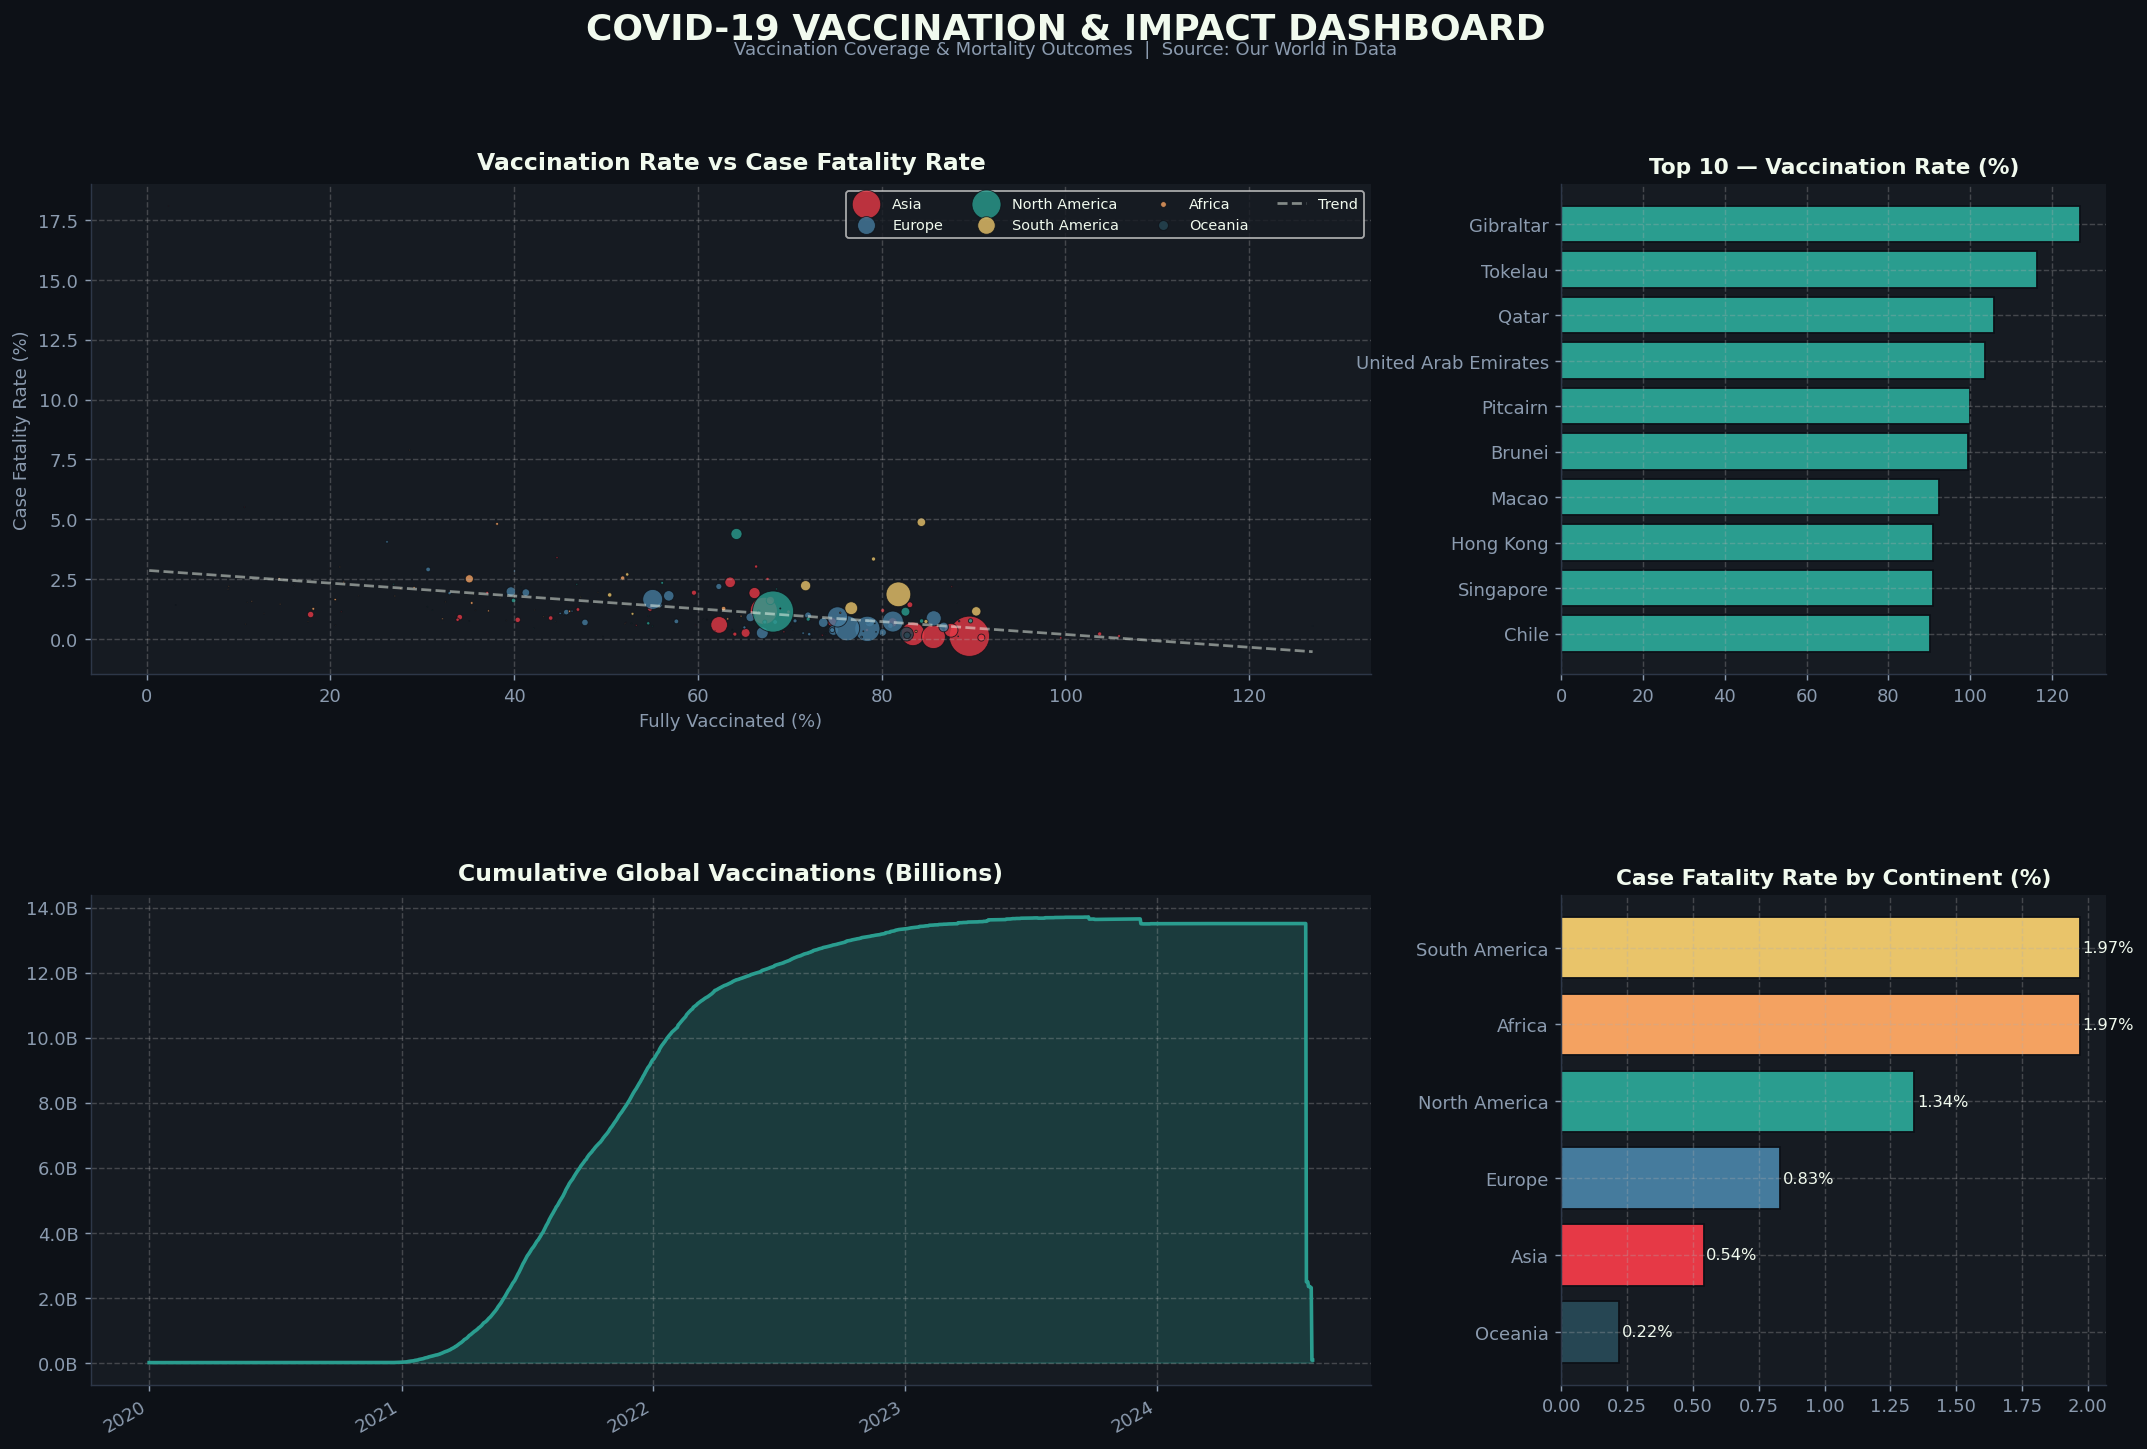

Dashboard 3 saved.


In [5]:
fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle('COVID-19 VACCINATION & IMPACT DASHBOARD',
             fontsize=20, fontweight='bold', color=WHITE, y=0.99)
fig.text(0.5, 0.963, 'Vaccination Coverage & Mortality Outcomes  |  Source: Our World in Data',
         ha='center', fontsize=10, color='#8B9BAF')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Scatter: Vacc vs Death Rate (row 0, col 0-1) ─────────────────────────────
scatter_df = latest[
    latest['vacc_rate'].notna() &
    latest['death_rate'].notna() &
    (latest['total_cases'] > 10000)
].copy()

ax_s = fig.add_subplot(gs[0, 0:2])
ax_s.set_facecolor('#161B22')
for cont, color in CONT_COLORS.items():
    sub = scatter_df[scatter_df['continent'] == cont]
    ax_s.scatter(sub['vacc_rate'], sub['death_rate'],
                 label=cont, color=color,
                 s=sub['total_cases']/2e5,
                 alpha=0.8, edgecolors=BG, linewidth=0.5)

x_v = scatter_df['vacc_rate'].dropna()
y_v = scatter_df.loc[x_v.index, 'death_rate'].dropna()
ci  = x_v.index.intersection(y_v.index)
m, b = np.polyfit(x_v[ci], y_v[ci], 1)
xl = np.linspace(x_v.min(), x_v.max(), 100)
ax_s.plot(xl, m*xl + b, '--', color=WHITE, linewidth=1.5,
          alpha=0.5, label='Trend')
ax_s.set_title('Vaccination Rate vs Case Fatality Rate',
               color=WHITE, fontsize=13, fontweight='bold', pad=8)
ax_s.set_xlabel('Fully Vaccinated (%)', color='#8B9BAF')
ax_s.set_ylabel('Case Fatality Rate (%)', color='#8B9BAF')
ax_s.legend(facecolor='#161B22', labelcolor=WHITE, fontsize=8, ncol=4)
ax_s.tick_params(colors='#8B9BAF')
for spine in ax_s.spines.values(): spine.set_color('#2D3748')

# ── Top 10 Vaccination Rate (row 0, col 2) ────────────────────────────────────
top10_vacc = latest[latest['vacc_rate'].notna()].nlargest(10, 'vacc_rate')
ax_vacc = fig.add_subplot(gs[0, 2])
ax_vacc.set_facecolor('#161B22')
ax_vacc.barh(top10_vacc['location'], top10_vacc['vacc_rate'],
             color=ACCENT3, edgecolor=BG)
ax_vacc.set_title('Top 10 — Vaccination Rate (%)',
                  color=WHITE, fontsize=12, fontweight='bold')
ax_vacc.invert_yaxis()
ax_vacc.tick_params(colors='#8B9BAF')
for spine in ax_vacc.spines.values(): spine.set_color('#2D3748')

# ── Cumulative Vacc Timeline (row 1, col 0-1) ─────────────────────────────────
global_vacc = (df.groupby('date')['total_vaccinations']
                 .sum()
                 .reset_index())
ax_vt = fig.add_subplot(gs[1, 0:2])
ax_vt.set_facecolor('#161B22')
ax_vt.fill_between(global_vacc['date'],
                   global_vacc['total_vaccinations']/1e9,
                   color=ACCENT3, alpha=0.25)
ax_vt.plot(global_vacc['date'],
           global_vacc['total_vaccinations']/1e9,
           color=ACCENT3, linewidth=2)
ax_vt.set_title('Cumulative Global Vaccinations (Billions)',
                color=WHITE, fontsize=13, fontweight='bold', pad=8)
ax_vt.tick_params(colors='#8B9BAF')
ax_vt.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
for spine in ax_vt.spines.values(): spine.set_color('#2D3748')
plt.setp(ax_vt.get_xticklabels(), rotation=30, ha='right', color='#8B9BAF')

# ── Death Rate by Continent (row 1, col 2) ────────────────────────────────────
cont_cfr = (latest.groupby('continent')
                  .agg(total_cases=('total_cases','sum'),
                       total_deaths=('total_deaths','sum'))
                  .reset_index())
cont_cfr['cfr'] = (cont_cfr['total_deaths'] / cont_cfr['total_cases'] * 100).round(2)
cont_cfr = cont_cfr.sort_values('cfr', ascending=True)

ax_cc = fig.add_subplot(gs[1, 2])
ax_cc.set_facecolor('#161B22')
colors_c = [CONT_COLORS.get(c, '#888') for c in cont_cfr['continent']]
ax_cc.barh(cont_cfr['continent'], cont_cfr['cfr'],
           color=colors_c, edgecolor=BG)
ax_cc.set_title('Case Fatality Rate by Continent (%)',
                color=WHITE, fontsize=12, fontweight='bold')
ax_cc.tick_params(colors='#8B9BAF')
for i, v in enumerate(cont_cfr['cfr']):
    ax_cc.text(v + 0.01, i, f'{v:.2f}%',
               va='center', fontsize=9, color=WHITE)
for spine in ax_cc.spines.values(): spine.set_color('#2D3748')

plt.savefig('dash_03_vaccination_impact.png', bbox_inches='tight',
            facecolor=BG, dpi=130)
plt.show()
print('Dashboard 3 saved.')


## 5️⃣  Dashboard 4 — Socioeconomic Intelligence

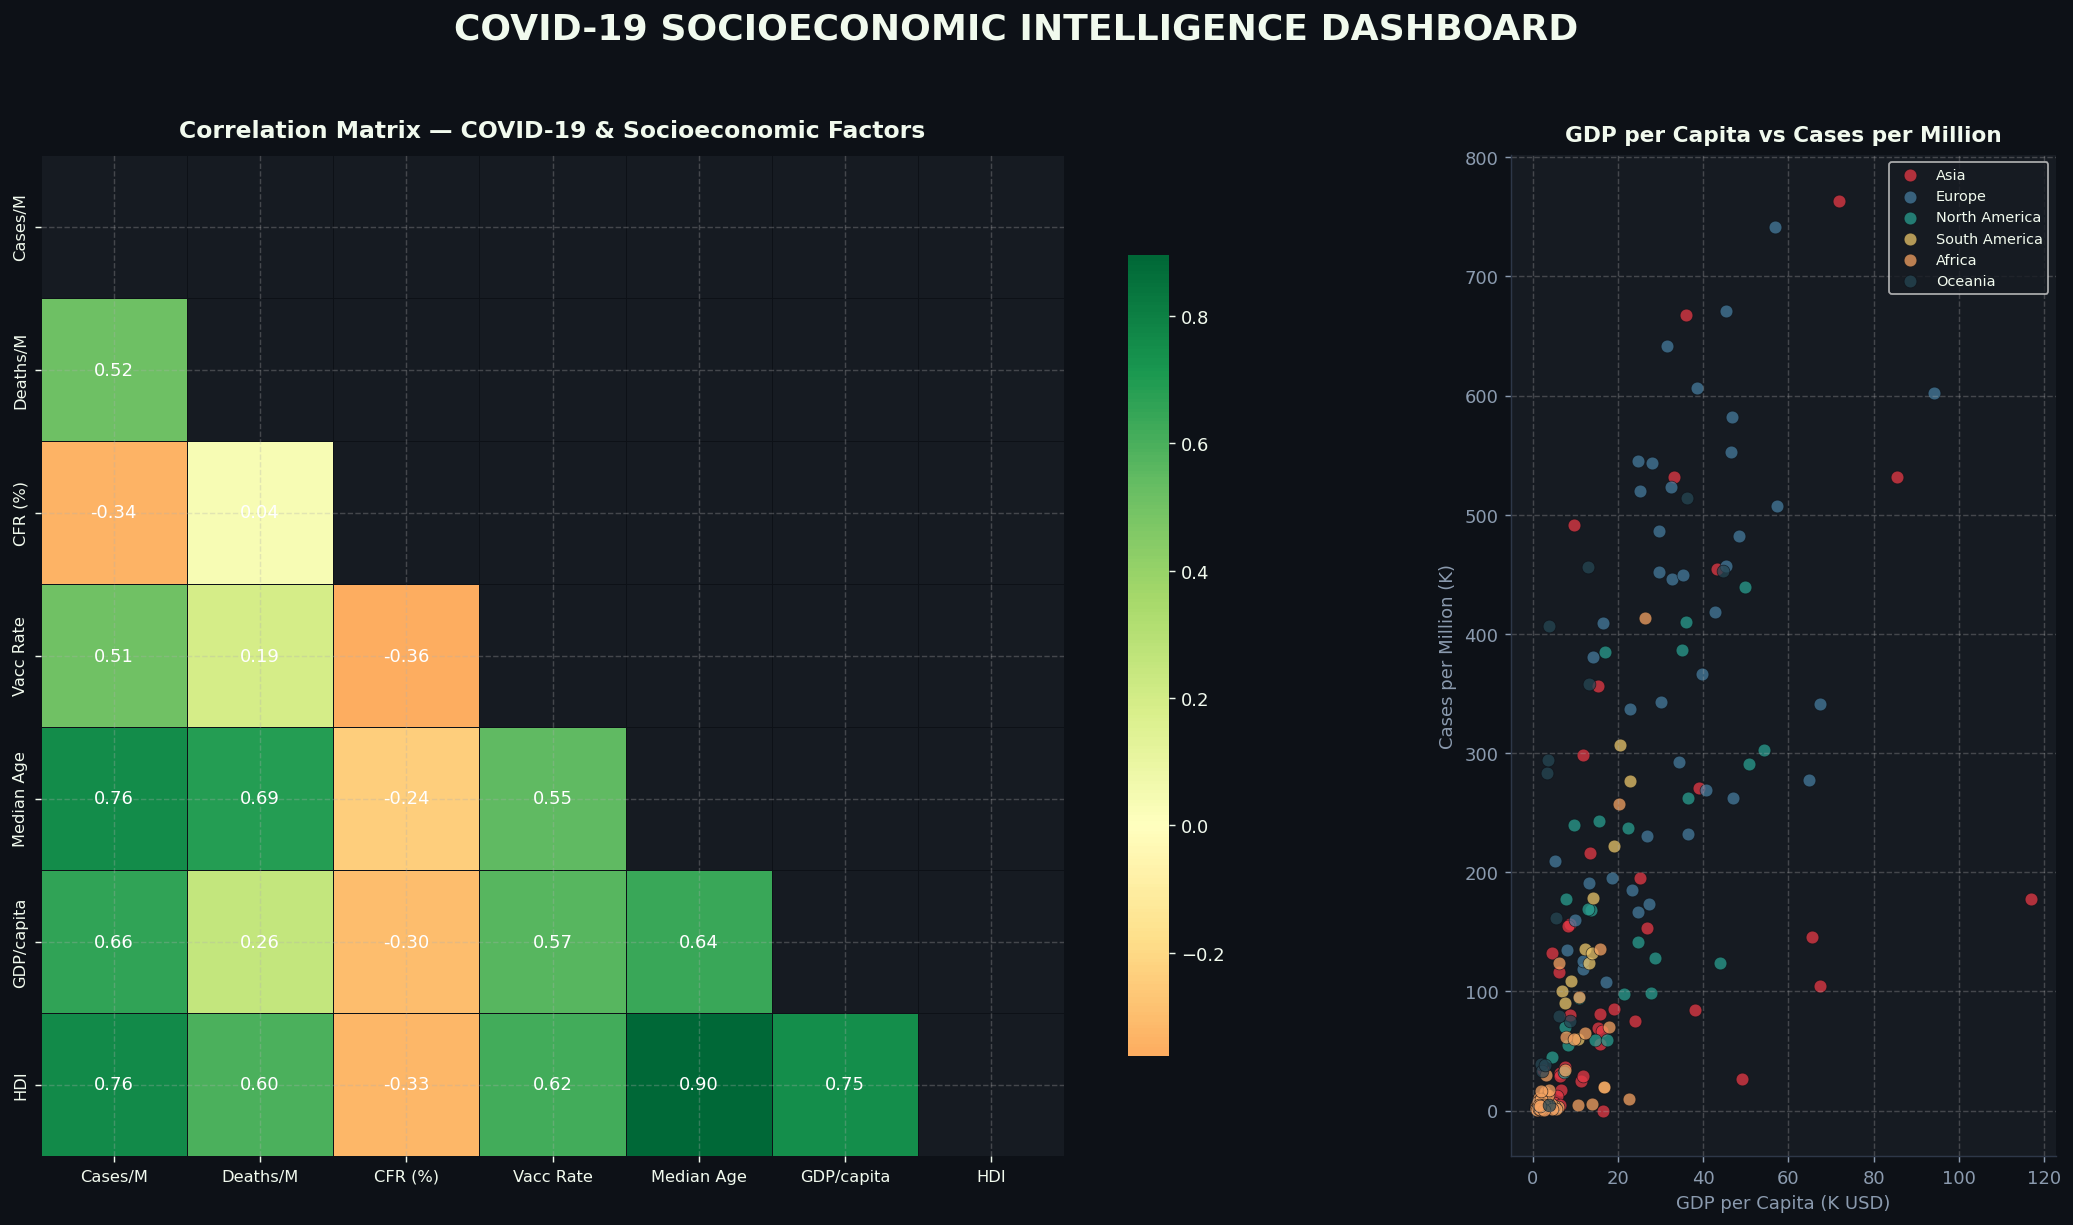

Dashboard 4 saved.


In [6]:
corr_cols = [
    'total_cases_per_million','total_deaths_per_million',
    'death_rate','vacc_rate',
    'median_age','gdp_per_capita','human_development_index'
]
labels_map = {
    'total_cases_per_million'  : 'Cases/M',
    'total_deaths_per_million' : 'Deaths/M',
    'death_rate'               : 'CFR (%)',
    'vacc_rate'                : 'Vacc Rate',
    'median_age'               : 'Median Age',
    'gdp_per_capita'           : 'GDP/capita',
    'human_development_index'  : 'HDI'
}
corr_df     = latest[corr_cols].dropna()
corr_matrix = corr_df.corr()
corr_matrix.index   = [labels_map[c] for c in corr_matrix.index]
corr_matrix.columns = [labels_map[c] for c in corr_matrix.columns]

fig = plt.figure(figsize=(20, 10), facecolor=BG)
fig.suptitle('COVID-19 SOCIOECONOMIC INTELLIGENCE DASHBOARD',
             fontsize=20, fontweight='bold', color=WHITE, y=0.99)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Correlation Heatmap (col 0-1) ─────────────────────────────────────────────
ax_h = fig.add_subplot(gs[0, 0:2])
ax_h.set_facecolor('#161B22')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, mask=mask,
            linewidths=0.5, linecolor='#0D1117',
            ax=ax_h, annot_kws={'size': 10, 'color': 'white'},
            cbar_kws={'shrink': 0.8})
ax_h.set_title('Correlation Matrix — COVID-19 & Socioeconomic Factors',
               color=WHITE, fontsize=13, fontweight='bold', pad=10)
ax_h.tick_params(colors=WHITE, labelsize=9)
ax_h.figure.axes[-1].tick_params(colors=WHITE)

# ── GDP vs Cases per million scatter (col 2) ──────────────────────────────────
gdp_df = latest[latest['gdp_per_capita'].notna() &
                latest['total_cases_per_million'].notna()].copy()

ax_g = fig.add_subplot(gs[0, 2])
ax_g.set_facecolor('#161B22')
for cont, color in CONT_COLORS.items():
    sub = gdp_df[gdp_df['continent'] == cont]
    ax_g.scatter(sub['gdp_per_capita']/1e3,
                 sub['total_cases_per_million']/1e3,
                 label=cont, color=color,
                 alpha=0.75, edgecolors=BG, linewidth=0.4, s=50)

ax_g.set_title('GDP per Capita vs Cases per Million',
               color=WHITE, fontsize=12, fontweight='bold', pad=8)
ax_g.set_xlabel('GDP per Capita (K USD)', color='#8B9BAF', fontsize=10)
ax_g.set_ylabel('Cases per Million (K)', color='#8B9BAF', fontsize=10)
ax_g.legend(facecolor='#161B22', labelcolor=WHITE, fontsize=8)
ax_g.tick_params(colors='#8B9BAF')
for spine in ax_g.spines.values(): spine.set_color('#2D3748')

plt.savefig('dash_04_socioeconomic.png', bbox_inches='tight',
            facecolor=BG, dpi=130)
plt.show()
print('Dashboard 4 saved.')


## 📋 Dashboard Summary

### What Each Dashboard Answers

| Dashboard | Question Answered |
|---|---|
| **1 — Global Overview** | How did the pandemic evolve globally over 4 years? |
| **2 — Country Deep-Dive** | Which countries were hit hardest and how did their waves differ? |
| **3 — Vaccination & Impact** | Did vaccination reduce deaths? Who got vaccinated fastest? |
| **4 — Socioeconomic Intelligence** | How do GDP, HDI, and age correlate with COVID outcomes? |

### Design Decisions
- **Dark theme** — reduces eye strain for extended analysis sessions and looks professional in presentations
- **Color consistency** — each continent gets a fixed color across all dashboards for instant recognition
- **KPI cards** — executive-level summary at the top of Dashboard 1 for decision-makers
- **7-day rolling averages** — reduces daily noise, reveals true trend direction
- **Bubble sizing** — encodes a third dimension (total cases) without adding another chart

### Key Visual Insights
- The Omicron wave dwarfs all previous waves in cases but not in deaths — vaccines changed the outcome
- Europe and North America dominate total cases; Africa's low numbers reflect undertesting
- Higher GDP countries show more cases per million but lower death rates — better healthcare, not worse spread
- The negative trend between vaccination rate and CFR is visible and statistically consistent

---
*Built by Mani Chelluri | Horizon TechX AI & Data Science Internship 2026*
